In [2]:
# Install any missing libraries
!pip install pandas numpy matplotlib seaborn scikit-learn --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_curve, auc, ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [3]:
from google.colab import files

uploaded = files.upload()   # 📂 a file picker will appear — upload your CSV

import io
filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]))

print("✅ Dataset loaded!")
print("Shape:", df.shape)
df.head()

Saving loan_prediction_dataset.csv to loan_prediction_dataset.csv
✅ Dataset loaded!
Shape: (2000, 7)


,Age,Income,Credit_Score,Loan_Amount,Loan_Term,Employment_Status,Loan_Approved
0,56,81788,334,15022,48,Employed,0
1,69,102879,781,21013,24,Self-Employed,1
2,46,58827,779,39687,60,Self-Employed,0
3,32,127188,364,16886,24,Unemployed,0
4,60,25655,307,26256,36,Unemployed,0


Basic Exploration

In [4]:
print("MISSING VALUES")
print("=" * 50)
print(df.isnull().sum())

print("\n\nTARGET DISTRIBUTION (Loan_Approved)")
print("=" * 50)
print(df['Loan_Approved'].value_counts())

MISSING VALUES
Age                  0
Income               0
Credit_Score         0
Loan_Amount          0
Loan_Term            0
Employment_Status    0
Loan_Approved        0
dtype: int64


TARGET DISTRIBUTION (Loan_Approved)
Loan_Approved
0    1658
1     342
Name: count, dtype: int64


visualization


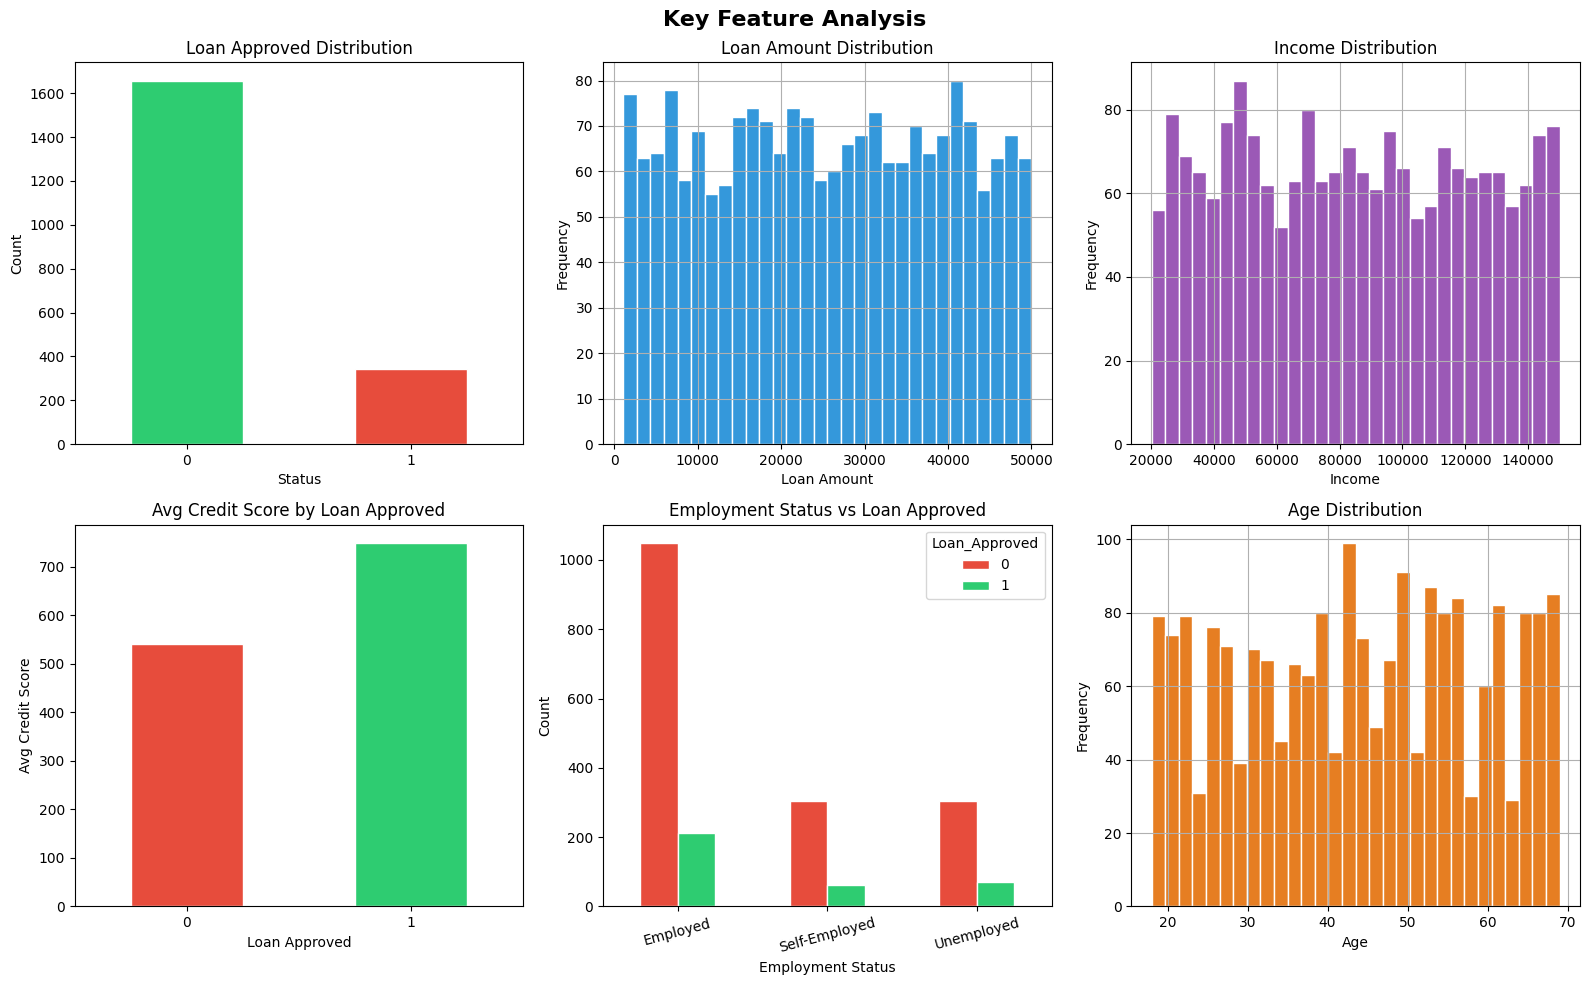

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Key Feature Analysis', fontsize=16, fontweight='bold')

# 1. Loan Approved Distribution
df['Loan_Approved'].value_counts().plot(
    kind='bar', ax=axes[0, 0],
    color=['#2ecc71', '#e74c3c'], edgecolor='white'
)
axes[0, 0].set_title('Loan Approved Distribution')
axes[0, 0].set_xlabel('Status')
axes[0, 0].set_ylabel('Count')
axes[0, 0].tick_params(axis='x', rotation=0)

# 2. Loan Amount Distribution
df['Loan_Amount'].hist(ax=axes[0, 1], bins=30,
                       color='#3498db', edgecolor='white')
axes[0, 1].set_title('Loan Amount Distribution')
axes[0, 1].set_xlabel('Loan Amount')
axes[0, 1].set_ylabel('Frequency')

# 3. Income Distribution
df['Income'].hist(ax=axes[0, 2], bins=30,
                  color='#9b59b6', edgecolor='white')
axes[0, 2].set_title('Income Distribution')
axes[0, 2].set_xlabel('Income')
axes[0, 2].set_ylabel('Frequency')

# 4. Credit Score vs Loan Approved
df.groupby(['Loan_Approved'])['Credit_Score'].mean().plot(
    kind='bar', ax=axes[1, 0],
    color=['#e74c3c', '#2ecc71'], edgecolor='white'
)
axes[1, 0].set_title('Avg Credit Score by Loan Approved')
axes[1, 0].set_xlabel('Loan Approved')
axes[1, 0].set_ylabel('Avg Credit Score')
axes[1, 0].tick_params(axis='x', rotation=0)

# 5. Employment Status vs Loan Approved
emp_counts = df.groupby(['Employment_Status', 'Loan_Approved']).size().unstack()
emp_counts.plot(kind='bar', ax=axes[1, 1],
                color=['#e74c3c', '#2ecc71'], edgecolor='white')
axes[1, 1].set_title('Employment Status vs Loan Approved')
axes[1, 1].set_xlabel('Employment Status')
axes[1, 1].set_ylabel('Count')
axes[1, 1].tick_params(axis='x', rotation=15)

# 6. Age Distribution
df['Age'].hist(ax=axes[1, 2], bins=30,
               color='#e67e22', edgecolor='white')
axes[1, 2].set_title('Age Distribution')
axes[1, 2].set_xlabel('Age')
axes[1, 2].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('fig1_eda_features.png', dpi=150, bbox_inches='tight')
plt.show()




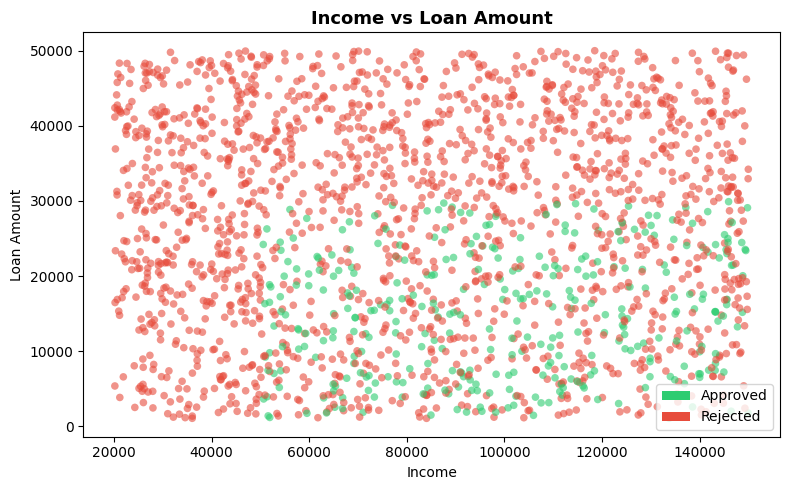

In [18]:
# Income vs Loan Amount Scatter
plt.figure(figsize=(8, 5))
colors = df['Loan_Approved'].map({1: '#2ecc71', 0: '#e74c3c'})
plt.scatter(df['Income'], df['Loan_Amount'],
            c=colors, alpha=0.6, edgecolors='none', s=30)
plt.title('Income vs Loan Amount', fontsize=13, fontweight='bold')
plt.xlabel('Income')
plt.ylabel('Loan Amount')
from matplotlib.patches import Patch
legend_els = [Patch(facecolor='#2ecc71', label='Approved'),
              Patch(facecolor='#e74c3c', label='Rejected')]
plt.legend(handles=legend_els)
plt.tight_layout()
plt.savefig('fig2_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

handle missing values

In [7]:
df_model = df.copy()

# Drop ID column if it exists
for col in ['Loan_ID', 'ID', 'id']:
    if col in df_model.columns:
        df_model.drop(columns=[col], inplace=True)

# Categorical columns — fill with mode
cat_cols = ['Employment_Status']
for col in cat_cols:
    if col in df_model.columns:
        df_model[col].fillna(df_model[col].mode()[0], inplace=True)

# Numerical columns — fill with median
num_cols = ['Age', 'Income', 'Credit_Score', 'Loan_Amount', 'Loan_Term']
for col in num_cols:
    if col in df_model.columns:
        df_model[col].fillna(df_model[col].median(), inplace=True)

print("✅ Missing values after imputation:")
print(df_model.isnull().sum())

✅ Missing values after imputation:
Age                  0
Income               0
Credit_Score         0
Loan_Amount          0
Loan_Term            0
Employment_Status    0
Loan_Approved        0
dtype: int64


In [ ]:
Encode Categorical Variables

In [8]:
le = LabelEncoder()

# Encode all object (text) columns
for col in df_model.select_dtypes(include='object').columns:
    df_model[col] = le.fit_transform(df_model[col].astype(str))

print("✅ Encoding done! Preview:")
df_model.head()

✅ Encoding done! Preview:


,Age,Income,Credit_Score,Loan_Amount,Loan_Term,Employment_Status,Loan_Approved
0,56,81788,334,15022,48,0,0
1,69,102879,781,21013,24,1,1
2,46,58827,779,39687,60,1,0
3,32,127188,364,16886,24,2,0
4,60,25655,307,26256,36,2,0


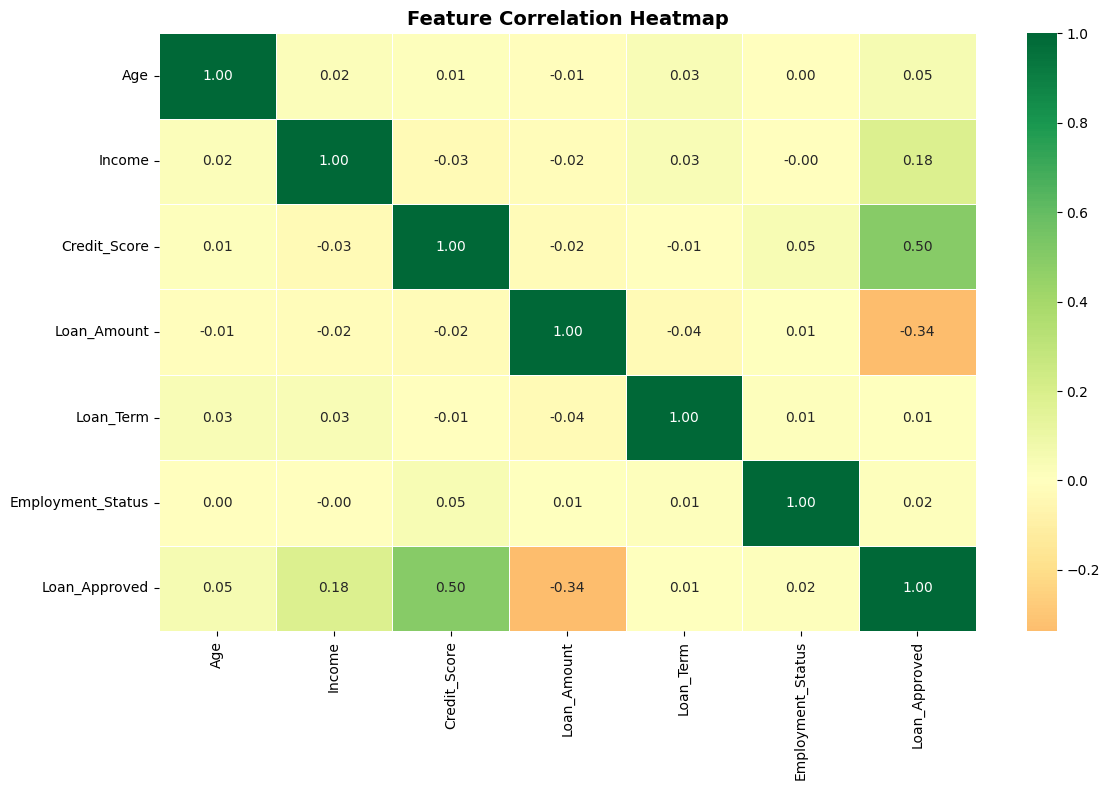

In [21]:
plt.figure(figsize=(12, 8))

sns.heatmap(df_model.corr(),
            annot=True,
            fmt='.2f',
            cmap='RdYlGn',
            center=0,
            linewidths=0.5,
            linecolor='white')

plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()

plt.savefig('fig3_correlation_heatmap.png', dpi=150, bbox_inches='tight')  # ← saves image
plt.show()

Prepare Features & Split

In [9]:
# Target column is Loan_Approved
X = df_model.drop(columns=['Loan_Approved'])
y = df_model['Loan_Approved']

print("Feature columns:", list(X.columns))
print("Target classes:", y.unique())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n✅ Train size: {X_train.shape[0]}")
print(f"✅ Test size : {X_test.shape[0]}")

Feature columns: ['Age', 'Income', 'Credit_Score', 'Loan_Amount', 'Loan_Term', 'Employment_Status']
Target classes: [0 1]

✅ Train size: 1600
✅ Test size : 400


Train Logistic Regression

In [10]:
# Scale features (important for Logistic Regression)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# Train model
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_sc, y_train)

# Predict
y_pred_lr = lr_model.predict(X_test_sc)
acc_lr = accuracy_score(y_test, y_pred_lr)

print(f"✅ Logistic Regression Accuracy: {acc_lr * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

✅ Logistic Regression Accuracy: 91.00%

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.95      0.95       332
           1       0.75      0.71      0.73        68

    accuracy                           0.91       400
   macro avg       0.85      0.83      0.84       400
weighted avg       0.91      0.91      0.91       400



Train Decision Tree

In [11]:
dt_model = DecisionTreeClassifier(max_depth=5, min_samples_leaf=10, random_state=42)
dt_model.fit(X_train, y_train)

# Predict
y_pred_dt = dt_model.predict(X_test)
acc_dt = accuracy_score(y_test, y_pred_dt)

print(f"✅ Decision Tree Accuracy: {acc_dt * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

✅ Decision Tree Accuracy: 100.00%

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       332
           1       1.00      1.00      1.00        68

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400



Confusion Matrices

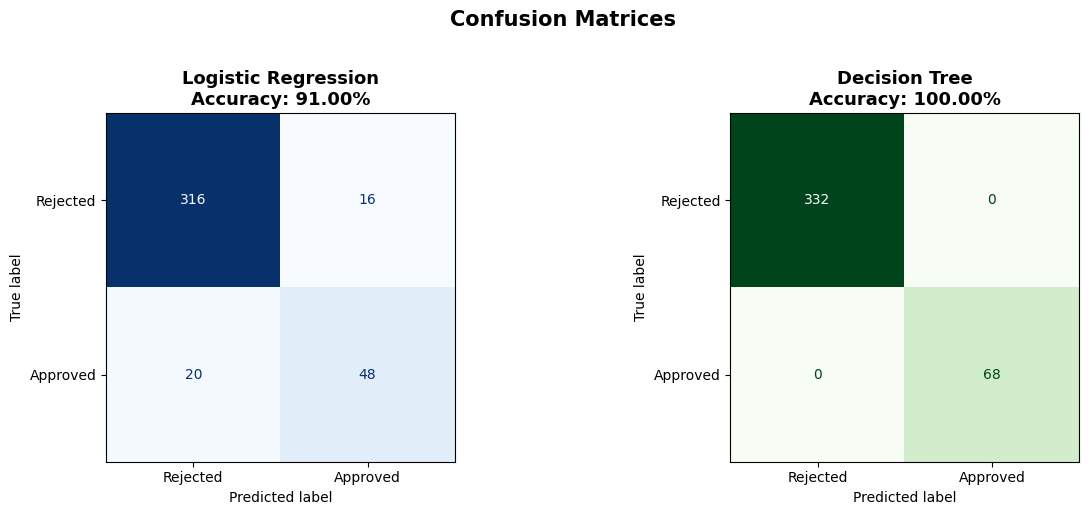

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Logistic Regression
cm_lr = confusion_matrix(y_test, y_pred_lr)
ConfusionMatrixDisplay(cm_lr, display_labels=['Rejected', 'Approved']).plot(
    ax=axes[0], colorbar=False, cmap='Blues'
)
axes[0].set_title(f'Logistic Regression\nAccuracy: {acc_lr*100:.2f}%',
                  fontsize=13, fontweight='bold')

# Decision Tree
cm_dt = confusion_matrix(y_test, y_pred_dt)
ConfusionMatrixDisplay(cm_dt, display_labels=['Rejected', 'Approved']).plot(
    ax=axes[1], colorbar=False, cmap='Greens'
)
axes[1].set_title(f'Decision Tree\nAccuracy: {acc_dt*100:.2f}%',
                  fontsize=13, fontweight='bold')

plt.suptitle('Confusion Matrices', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig4_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

ROC Curve & Feature Importance

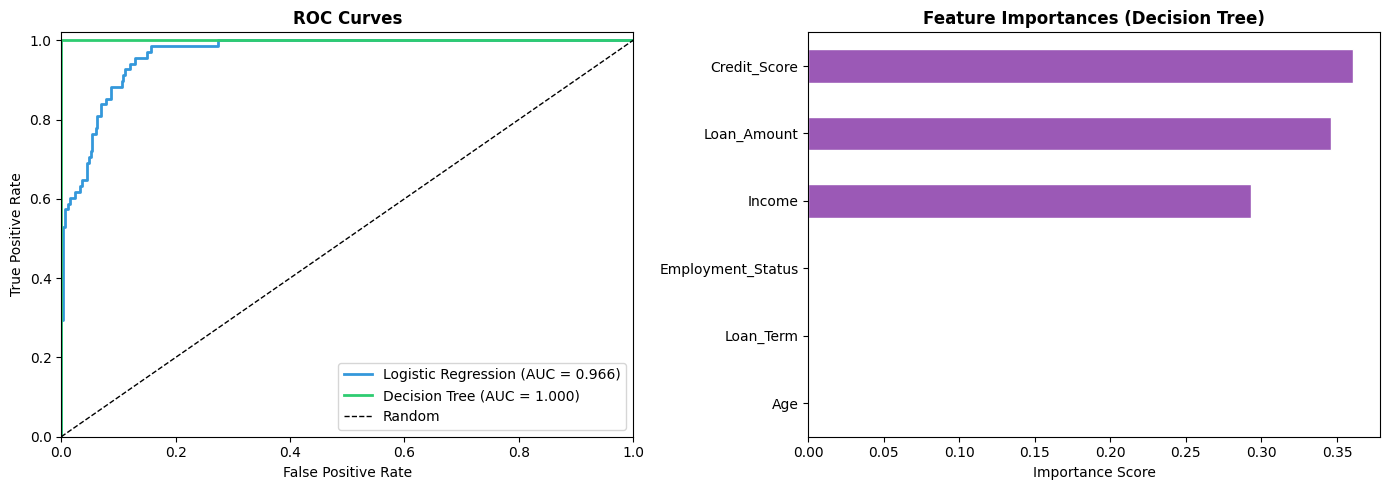

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curves
y_prob_lr = lr_model.predict_proba(X_test_sc)[:, 1]
y_prob_dt = dt_model.predict_proba(X_test)[:, 1]

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
auc_lr = auc(fpr_lr, tpr_lr)
auc_dt = auc(fpr_dt, tpr_dt)

axes[0].plot(fpr_lr, tpr_lr, color='#3498db', lw=2,
             label=f'Logistic Regression (AUC = {auc_lr:.3f})')
axes[0].plot(fpr_dt, tpr_dt, color='#2ecc71', lw=2,
             label=f'Decision Tree (AUC = {auc_dt:.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
axes[0].set_xlim([0, 1]); axes[0].set_ylim([0, 1.02])
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves', fontweight='bold')
axes[0].legend()

# Feature Importance (Decision Tree)
feat_imp = pd.Series(dt_model.feature_importances_,
                     index=X.columns).sort_values()
feat_imp.plot(kind='barh', ax=axes[1], color='#9b59b6', edgecolor='white')
axes[1].set_title('Feature Importances (Decision Tree)', fontweight='bold')
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig('fig5_roc_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

Final Model Comparison

In [14]:
from sklearn.metrics import precision_score, recall_score, f1_score

summary = pd.DataFrame({
    'Model':     ['Logistic Regression', 'Decision Tree'],
    'Accuracy':  [f'{acc_lr*100:.2f}%',  f'{acc_dt*100:.2f}%'],
    'Precision': [f'{precision_score(y_test, y_pred_lr)*100:.2f}%',
                  f'{precision_score(y_test, y_pred_dt)*100:.2f}%'],
    'Recall':    [f'{recall_score(y_test, y_pred_lr)*100:.2f}%',
                  f'{recall_score(y_test, y_pred_dt)*100:.2f}%'],
    'F1-Score':  [f'{f1_score(y_test, y_pred_lr)*100:.2f}%',
                  f'{f1_score(y_test, y_pred_dt)*100:.2f}%'],
    'AUC-ROC':   [f'{auc_lr:.4f}',       f'{auc_dt:.4f}'],
})

print("=" * 65)
print("           FINAL MODEL PERFORMANCE SUMMARY")
print("=" * 65)
print(summary.to_string(index=False))

           FINAL MODEL PERFORMANCE SUMMARY
              Model Accuracy Precision  Recall F1-Score AUC-ROC
Logistic Regression   91.00%    75.00%  70.59%   72.73%  0.9659
      Decision Tree  100.00%   100.00% 100.00%  100.00%  1.0000


In [15]:
# Step 5 - EDA plots

# Step 5 - Scatter plot
plt.savefig('fig2_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

# Step 8 - Correlation heatmap
plt.savefig('fig3_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Step 12 - Confusion matrices
plt.savefig('fig4_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Step 13 - ROC + Feature Importance
plt.savefig('fig5_roc_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>